# Spline-based boundary parametrization for inverse design

In [Tutorial 5: Boundary Gradients](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd5BoundaryGradients.html), we showed how to optimize a waveguide taper using a `PolySlab` with a curvature penalty to ensure smooth, fabricable designs.

In this notebook, we present an alternative approach using **differentiable spline interpolation** (`interpolate_spline`) to parametrize the taper sidewall. By optimizing a small number of spline control points rather than all vertices independently, we get inherently smooth designs without needing an explicit curvature penalty.

We compare both approaches at the end and show that they achieve similar performance.

<img src="img/adjoint_5.png" width=400 alt="Schematic of the waveguide taper">

In [35]:
import autograd as ag
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import optax
import tidy3d as td
import tidy3d.web as web

## Set up

We define the same waveguide taper problem as in [Tutorial 5](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd5BoundaryGradients.html): a non-adiabatic taper between a narrow (0.5λ) and wide (5λ) Si3N4 waveguide. See Tutorial 5 for detailed explanations of the problem setup.

In [36]:
wavelength = 1.0
freq0 = td.C_0 / wavelength

wg_width_in = 0.5 * wavelength
wg_width_out = 5.0 * wavelength

wg_medium = td.material_library["Si3N4"]["Philipp1973Sellmeier"]

wg_length = 1 * wavelength
taper_length = 10.0

spc_pml = 1.5 * wavelength

Lx = wg_length + taper_length + wg_length
Ly = spc_pml + max(wg_width_in, wg_width_out) + spc_pml

In [37]:
num_points = 101
x_start = -taper_length / 2
x_end = +taper_length / 2
xs = np.linspace(x_start, x_end, num_points)

ys0 = (wg_width_in + (wg_width_out - wg_width_in) * (xs - x_start) / (x_end - x_start)) / 2.0

We define the same helper functions used in Tutorial 5 for creating the taper geometry and simulation.

In [38]:
def make_taper(xs, ys) -> td.PolySlab:
    """Create a PolySlab for the taper based on the supplied x and y values."""
    vertices = anp.concatenate(
        [
            anp.column_stack((xs, ys)),
            anp.column_stack((xs[::-1], -ys[::-1])),
        ]
    )
    return td.PolySlab(vertices=vertices, slab_bounds=(-td.inf, +td.inf), axis=2)

In [39]:
def make_sim(xs, ys, include_field_mnt: bool = False) -> td.Simulation:
    """Make a td.Simulation containing the taper."""

    wg_in_box = td.Box.from_bounds(
        rmin=(-Lx, -wg_width_in / 2, -td.inf),
        rmax=(-Lx / 2 + wg_length + 0.01, +wg_width_in / 2, +td.inf),
    )

    wg_out_box = td.Box.from_bounds(
        rmin=(+Lx / 2 - wg_length - 0.01, -wg_width_out / 2, -td.inf),
        rmax=(+Lx, +wg_width_out / 2, +td.inf),
    )

    taper_geo = make_taper(xs, ys)

    wg_in = td.Structure(geometry=wg_in_box, medium=wg_medium)
    wg_out = td.Structure(geometry=wg_out_box, medium=wg_medium)
    taper = td.Structure(geometry=taper_geo, medium=wg_medium)

    mode_source = td.ModeSource(
        center=(-Lx / 2 + wg_length / 2, 0, 0),
        size=(0, td.inf, td.inf),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
        direction="+",
    )

    mode_monitor = td.ModeMonitor(
        center=(+Lx / 2 - wg_length / 2, 0, 0),
        size=(0, td.inf, td.inf),
        freqs=[freq0],
        mode_spec=td.ModeSpec(),
        name="mode",
    )

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, td.inf, 0),
        freqs=[freq0],
        name="field",
    )

    return td.Simulation(
        size=(Lx, Ly, 0),
        structures=[taper, wg_in, wg_out],
        monitors=[mode_monitor, field_monitor] if include_field_mnt else [mode_monitor],
        sources=[mode_source],
        run_time=100 / freq0,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=20),
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
        symmetry=(0, +1, 0),
    )

In [40]:
def measure_transmission(sim_data: td.SimulationData) -> float:
    """Measure the first order transmission."""
    amp_data = sim_data["mode"].amps
    amp = amp_data.sel(f=freq0, direction="+", mode_index=0).values
    return anp.sum(abs(amp) ** 2)

In [41]:
def get_ys(parameters: np.ndarray) -> np.ndarray:
    """Convert arbitrary parameters to y values for the vertices (parameter (-inf, inf) -> wg width of (wg_width_out, wg_width_in)."""

    params_between_0_1 = (anp.tanh(np.pi * parameters) + 1.0) / 2.0

    params_scaled = params_between_0_1 * (wg_width_out - wg_width_in) / 2.0
    ys = params_scaled + wg_width_in / 2
    return ys


def get_params(ys: np.ndarray) -> np.ndarray:
    """inverse of above, get parameters from ys"""
    params_scaled = ys - wg_width_in / 2
    params_between_0_1 = 2 * params_scaled / (wg_width_out - wg_width_in)
    tanh_pi_params = 2 * params_between_0_1 - 1
    params = np.arctanh(tanh_pi_params) / np.pi
    return params


# assert that the inverse function works properly
params_test = 2 * (np.random.random((10,)) - 0.5)
ys_test = get_ys(params_test)
assert np.allclose(get_params(ys_test), params_test)

In [42]:
def optimize(params0, grad_fn, num_steps, learning_rate):
    """Runs optimization loop.

    Parameters:
    -----------
    params0: np.ndarray
        The initial parameters.
    grad_fn: function
        The gradient function, ag.value_and_grad(objective).
    num_steps: int
        The number of steps to run the optimization.
    learning_rate: float
        The learning rate for the optimizer.

    Returns:
    --------
    objective_history: list
        The history of objective values.
    param_history: list
        The history of parameters per iteration.
    """
    # initialize adam optimizer with starting parameters
    params = np.array(params0).copy()
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(params)

    # store history
    objective_history = []
    param_history = [params]

    for i in range(num_steps):
        # compute gradient and current objective function value
        value, gradient = grad_fn(params, verbose=False)

        # outputs
        print(f"step = {i + 1}")
        print(f"\tJ = {value:.4e}")
        print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

        # compute and apply updates to the optimizer based on gradient
        updates, opt_state = optimizer.update(-gradient, opt_state, params)
        params[:] = optax.apply_updates(params, updates)

        # save history
        objective_history.append(value)
        param_history.append(params)

    return objective_history, param_history

### Initial Design

We start from a linear taper and run the initial simulation to establish a baseline.

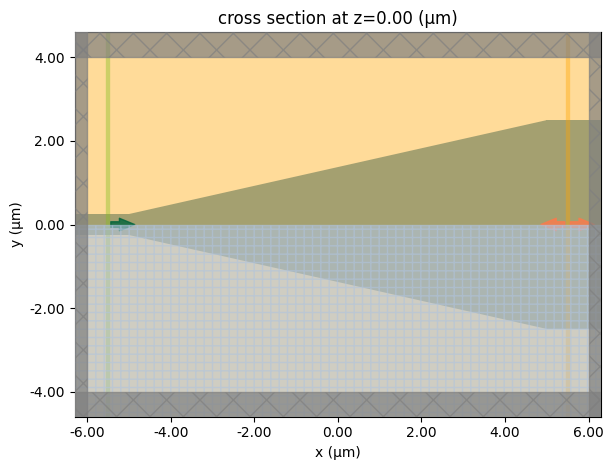

In [43]:
# desired ys
ys0 = np.linspace(wg_width_in / 2 + 0.001, wg_width_out / 2 - 0.001, num_points)

# corresponding parameters
params0 = get_params(ys0)

# make and run the initial simulation
sim = make_sim(xs, get_ys(params0), include_field_mnt=True)
ax = sim.plot(z=0)

In [44]:
sim_data = web.run(sim, task_name="taper fields", verbose=False)

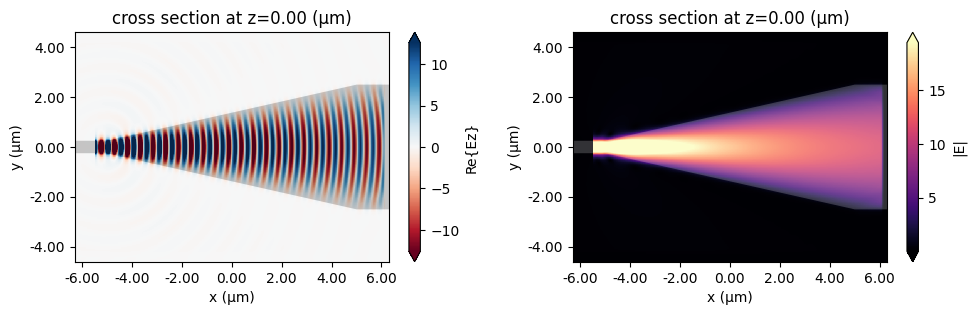

In [45]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
sim_data.plot_field(field_monitor_name="field", field_name="Ez", val="real", ax=ax1)
sim_data.plot_field(field_monitor_name="field", field_name="E", val="abs", ax=ax2)
plt.show()

## Spline Interpolation

Instead of optimizing all vertex positions independently (which requires a curvature penalty to ensure smooth designs), we can parametrize the sidewall using **spline interpolation**. We optimize a small number of spline control points, and `interpolate_spline` smoothly interpolates between them.

Key advantages:
- Fewer design parameters (e.g., 21 control points instead of 101 vertices)
- Inherently smooth designs — no explicit curvature penalty needed
- `interpolate_spline` is fully autograd-differentiable

Let's import `interpolate_spline` and see a simple example:

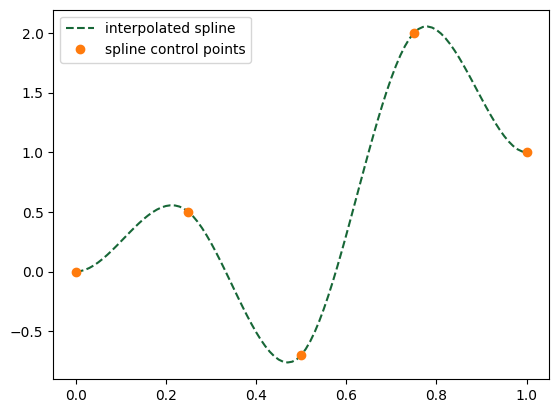

In [46]:
from tidy3d.plugins.autograd import interpolate_spline

# Define a set of control points
xs_control = np.linspace(0, 1, 5)
ys_control = np.array([0, 0.5, -0.7, 2, 1])

# Interpolate the spline
xs_spline, ys_spline = interpolate_spline(
    xs_control, ys_control, num_points=101, order=3, endpoint_derivatives=(0, 0)
)

# Plot the resulting spline
fig, ax = plt.subplots()
ax.plot(xs_spline, ys_spline, "--", label="interpolated spline")
ax.plot(xs_control, ys_control, "o", label="spline control points")
ax.legend()
plt.show()

## Spline-based Taper Optimization

We parametrize the taper sidewall using 21 spline control points, interpolated to 101 vertices. Setting `endpoint_derivatives=(0, 0)` ensures there is no slope discontinuity at the taper endpoints.

Here is the initial spline parametrization:

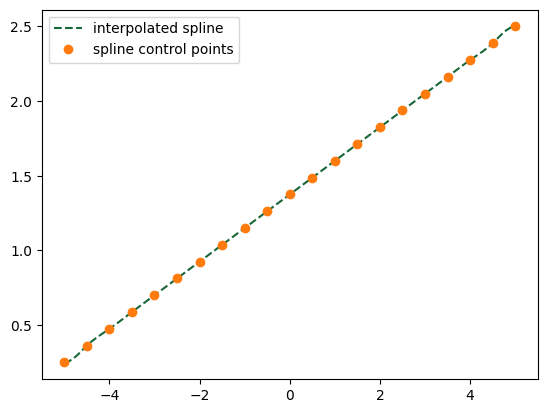

In [47]:
# Choose the number of spline control points
num_spline_points = 21
num_points_interpolated = 101

# Define the starting positions of the spline control points
xs_spline_control = np.linspace(x_start, x_end, num_spline_points)
ys0_spline_control = (
    wg_width_in + (wg_width_out - wg_width_in) * (xs_spline_control - x_start) / (x_end - x_start)
) / 2.0

xs_spline, ys_spline = interpolate_spline(
    xs_spline_control,
    ys0_spline_control,
    num_points=num_points_interpolated,
    order=3,
    endpoint_derivatives=(0, 0),
)

fig, ax = plt.subplots()
ax.plot(xs_spline, ys_spline, "--", label="interpolated spline")
ax.plot(xs_spline_control, ys0_spline_control, "o", label="spline control points")
ax.legend()
plt.show()

We modify the simulation and objective functions to use the spline parametrization. The `make_sim_params_spline` function converts the spline control point parameters to interpolated vertices before constructing the simulation. The `objective_spline` function does not include a curvature penalty since the spline naturally produces smooth curves.

In [48]:
def make_sim_params_spline(
    parameters: np.ndarray, include_field_mnt: bool = False
) -> td.Simulation:
    """Make the simulation out of raw parameters."""
    ys_spline_control = get_ys(parameters)
    xs_spline, ys_spline = interpolate_spline(
        xs_spline_control,
        ys_spline_control,
        num_points=num_points_interpolated,
        order=3,
        endpoint_derivatives=(0, 0),
    )
    return make_sim(xs_spline, ys_spline, include_field_mnt=include_field_mnt)


def objective_spline(parameters: np.ndarray, verbose: bool = False) -> float:
    """Construct simulation, run, and measure transmission."""
    sim = make_sim_params_spline(parameters, include_field_mnt=False)
    sim_data = web.run(sim, task_name="autograd taper", verbose=verbose)
    return measure_transmission(sim_data)

Let's test the gradient computation:

In [49]:
params0_spline = get_params(ys0_spline_control)
grad_fn_spline = ag.value_and_grad(objective_spline)
val, grad = grad_fn_spline(params0_spline, verbose=False)

print(f"objective = {val:.2e}")
print(f"gradient = {np.nan_to_num(grad)}")

/var/folders/hj/gqgpl1cx7w94ffrwz7_2k7jc0000gn/T/ipykernel_56325/3173695798.py:16: RuntimeWarning: divide by zero encountered in arctanh
  params = np.arctanh(tanh_pi_params) / np.pi


objective = 7.06e-01
gradient = [ 0.         -1.01483401 -0.27203204  1.41582635  1.82799925  0.29959009
 -0.02209479  0.24993958 -0.0101532  -0.18417024 -0.12013521 -0.1998953
 -0.18800349 -0.18431235 -0.15737235 -0.12103836 -0.08236785 -0.04631347
 -0.0215403  -0.00469762  0.        ]


The gradient is working, so let's run the full optimization:

In [51]:
# hyperparameters
num_steps = 50
learning_rate = 0.01

objective_history_spline, param_history_spline = optimize(
    params0_spline, grad_fn_spline, num_steps, learning_rate
)

step = 1
	J = 7.0581e-01
	grad_norm = 2.6095e+00
step = 2
	J = 7.6616e-01
	grad_norm = 2.3726e+00
step = 3
	J = 8.2081e-01
	grad_norm = 2.0722e+00
step = 4
	J = 8.6705e-01
	grad_norm = 1.7196e+00
step = 5
	J = 9.0422e-01
	grad_norm = 1.3819e+00
step = 6
	J = 9.3276e-01
	grad_norm = 1.0990e+00
step = 7
	J = 9.5427e-01
	grad_norm = 8.5814e-01
step = 8
	J = 9.6699e-01
	grad_norm = 6.8153e-01
step = 9
	J = 9.7335e-01
	grad_norm = 7.6170e-01
step = 10
	J = 9.7619e-01
	grad_norm = 8.0551e-01
step = 11
	J = 9.7540e-01
	grad_norm = 9.5447e-01
step = 12
	J = 9.7423e-01
	grad_norm = 9.7515e-01
step = 13
	J = 9.7534e-01
	grad_norm = 8.0057e-01
step = 14
	J = 9.7669e-01
	grad_norm = 6.4847e-01
step = 15
	J = 9.7625e-01
	grad_norm = 6.6216e-01
step = 16
	J = 9.7670e-01
	grad_norm = 6.4337e-01
step = 17
	J = 9.7778e-01
	grad_norm = 6.5424e-01
step = 18
	J = 9.7945e-01
	grad_norm = 6.4957e-01
step = 19
	J = 9.8178e-01
	grad_norm = 4.8710e-01
step = 20
	J = 9.8317e-01
	grad_norm = 5.0053e-01
step = 21

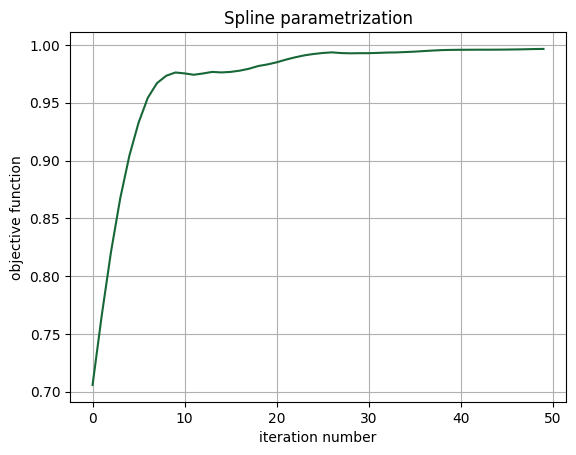

In [ ]:
ax = plt.plot(objective_history_spline)
plt.xlabel("iteration number")
plt.ylabel("objective function")
plt.title("Spline parametrization")
plt.grid()
plt.show()

Let's look at the best design:

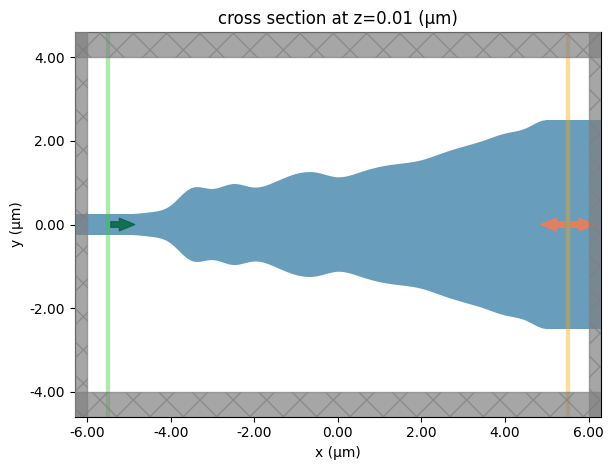

In [ ]:
params_best_spline = param_history_spline[np.argmax(objective_history_spline)]
sim_best_spline = make_sim_params_spline(params_best_spline, include_field_mnt=True)
ax = sim_best_spline.plot(z=0.01)

In [ ]:
sim_data_best_spline = td.web.run(sim_best_spline, task_name="taper spline final", verbose=False)

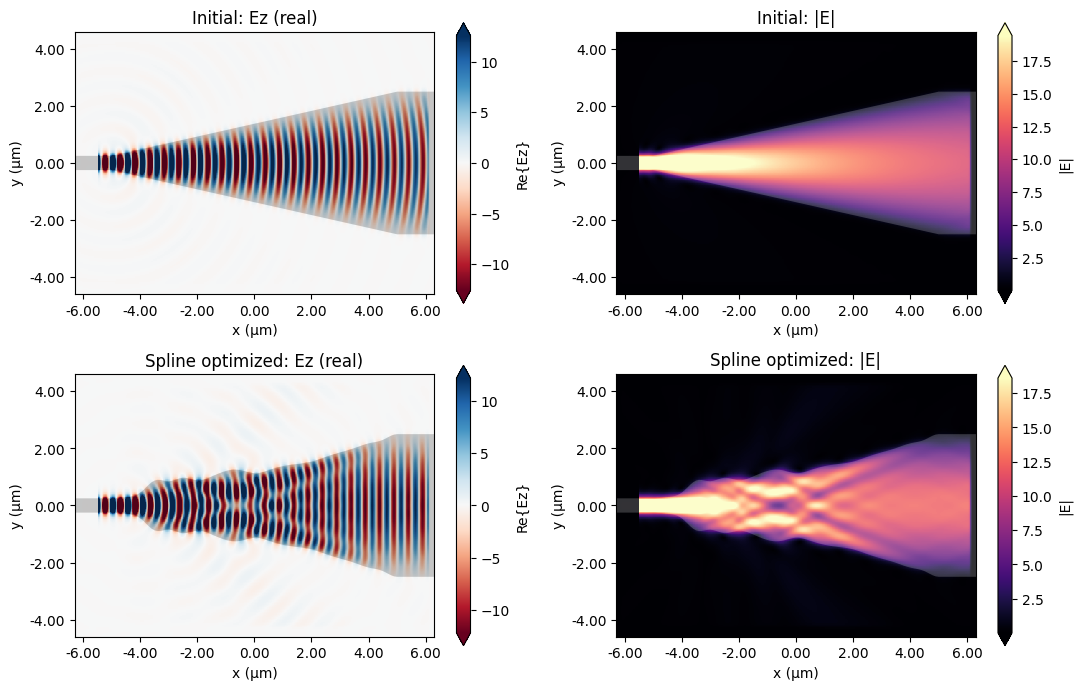

In [ ]:
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, tight_layout=True, figsize=(11, 7))

# plot original
sim_data.plot_field(field_monitor_name="field", field_name="Ez", val="real", ax=ax1)
sim_data.plot_field(field_monitor_name="field", field_name="E", val="abs", ax=ax2)
ax1.set_title("Initial: Ez (real)")
ax2.set_title("Initial: |E|")

# plot optimized
sim_data_best_spline.plot_field(field_monitor_name="field", field_name="Ez", val="real", ax=ax3)
sim_data_best_spline.plot_field(field_monitor_name="field", field_name="E", val="abs", ax=ax4)
ax3.set_title("Spline optimized: Ez (real)")
ax4.set_title("Spline optimized: |E|")

plt.show()

In [ ]:
transmission_start = float(measure_transmission(sim_data))
transmission_spline = float(measure_transmission(sim_data_best_spline))
print(
    f"Transmission improved from {(transmission_start * 100):.2f}% to {(transmission_spline * 100):.2f}%"
)

Transmission improved from 72.19% to 99.67%


## Comparison with Vertex + Curvature Penalty Approach

For comparison, let's also run the full vertex parametrization with a curvature penalty, as described in [Tutorial 5](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd5BoundaryGradients.html). This approach optimizes all 101 vertex positions independently and uses a penalty term to discourage sharp features.

In [ ]:
from tidy3d.plugins.autograd import make_curvature_penalty

curvature_penalty = make_curvature_penalty(min_radius=0.15)


def penalty(params: np.ndarray) -> float:
    """Compute curvature penalty for a set of parameters."""
    ys = get_ys(params)
    points = anp.array([xs, ys]).T
    return curvature_penalty(points)


def make_sim_params(parameters: np.ndarray, include_field_mnt: bool = False) -> td.Simulation:
    """Make the simulation out of raw parameters."""
    ys = get_ys(parameters)
    return make_sim(xs, ys, include_field_mnt=include_field_mnt)


def objective(parameters: np.ndarray, verbose: bool = False) -> float:
    """Construct simulation, run, and measure transmission (with curvature penalty)."""
    sim = make_sim_params(parameters, include_field_mnt=False)
    sim_data = web.run(sim, task_name="autograd taper", verbose=verbose)
    return measure_transmission(sim_data) - penalty(parameters)

In [ ]:
params0_vertex = get_params(
    np.linspace(wg_width_in / 2 + 0.001, wg_width_out / 2 - 0.001, num_points)
)
grad_fn_vertex = ag.value_and_grad(objective)

objective_history_vertex, param_history_vertex = optimize(
    params0_vertex, grad_fn_vertex, num_steps, learning_rate
)

step = 1
	J = 7.2187e-01
	grad_norm = 1.2287e+00
step = 2
	J = 7.6164e-01
	grad_norm = 2.0176e+00
step = 3
	J = 8.0581e-01
	grad_norm = 4.2498e+00
step = 4
	J = 8.3471e-01
	grad_norm = 3.3267e+00
step = 5
	J = 8.5934e-01
	grad_norm = 5.0893e+00
step = 6
	J = 8.8585e-01
	grad_norm = 4.9481e+00
step = 7
	J = 8.7458e-01
	grad_norm = 6.3633e+00
step = 8
	J = 8.9498e-01
	grad_norm = 5.7798e+00
step = 9
	J = 8.9671e-01
	grad_norm = 6.8874e+00
step = 10
	J = 9.0469e-01
	grad_norm = 5.2316e+00
step = 11
	J = 9.1577e-01
	grad_norm = 5.3975e+00
step = 12
	J = 9.3594e-01
	grad_norm = 5.7844e+00
step = 13
	J = 9.4537e-01
	grad_norm = 4.7955e+00
step = 14
	J = 9.3764e-01
	grad_norm = 5.7775e+00
step = 15
	J = 9.5789e-01
	grad_norm = 4.8862e+00
step = 16
	J = 9.6770e-01
	grad_norm = 3.3472e+00
step = 17
	J = 9.5967e-01
	grad_norm = 3.9893e+00
step = 18
	J = 9.5567e-01
	grad_norm = 5.1020e+00
step = 19
	J = 9.7125e-01
	grad_norm = 3.0085e+00
step = 20
	J = 9.7546e-01
	grad_norm = 2.6601e+00
step = 21

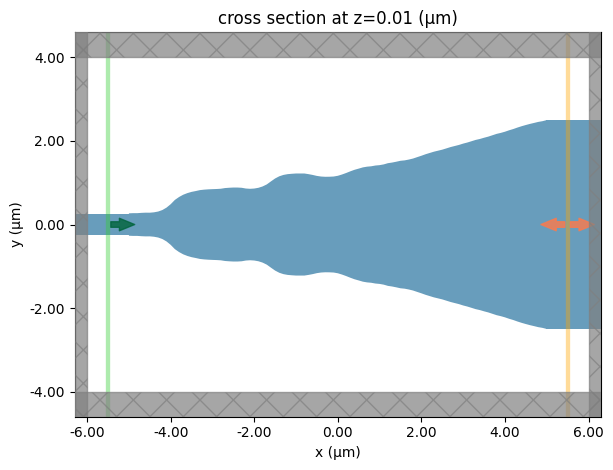

In [ ]:
params_best_vertex = param_history_vertex[np.argmax(objective_history_vertex)]
sim_best_vertex = make_sim_params(params_best_vertex, include_field_mnt=True)
ax = sim_best_vertex.plot(z=0.01)

In [ ]:
sim_data_best_vertex = td.web.run(sim_best_vertex, task_name="taper vertex final", verbose=False)

## Results

### Field and Transmission Comparison

Comparing the optimized field patterns and transmission from both approaches, we can see the fields are very similar and the transmission is within approximately 0.1%:

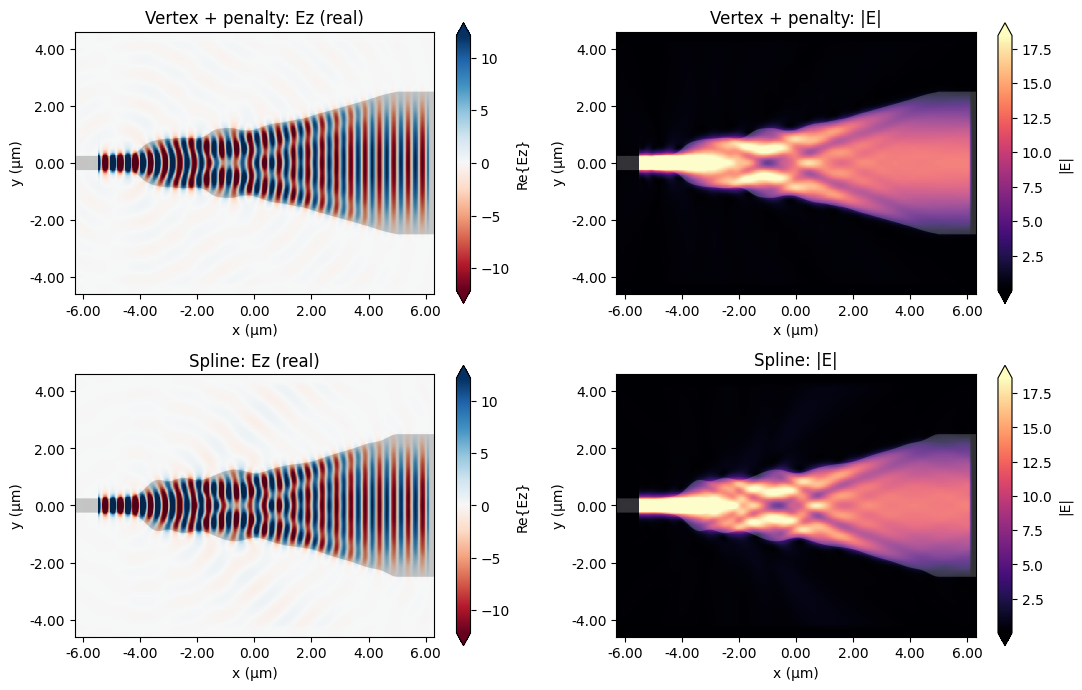

In [ ]:
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, tight_layout=True, figsize=(11, 7))

# plot vertex + penalty optimized design
sim_data_best_vertex.plot_field(field_monitor_name="field", field_name="Ez", val="real", ax=ax1)
sim_data_best_vertex.plot_field(field_monitor_name="field", field_name="E", val="abs", ax=ax2)
ax1.set_title("Vertex + penalty: Ez (real)")
ax2.set_title("Vertex + penalty: |E|")

# plot spline optimized design
sim_data_best_spline.plot_field(field_monitor_name="field", field_name="Ez", val="real", ax=ax3)
sim_data_best_spline.plot_field(field_monitor_name="field", field_name="E", val="abs", ax=ax4)
ax3.set_title("Spline: Ez (real)")
ax4.set_title("Spline: |E|")

plt.show()

In [ ]:
transmission_vertex = float(measure_transmission(sim_data_best_vertex))
transmission_spline = float(measure_transmission(sim_data_best_spline))
print(f"Transmission of the vertex + penalty design: {(transmission_vertex * 100):.2f}%")
print(f"Transmission of the spline design: {(transmission_spline * 100):.2f}%")

Transmission of the vertex + penalty design: 99.78%
Transmission of the spline design: 99.67%


### Curvature Comparison

We can compare the local curvature of the two optimized designs. The spline approach produces less curvature "noise".

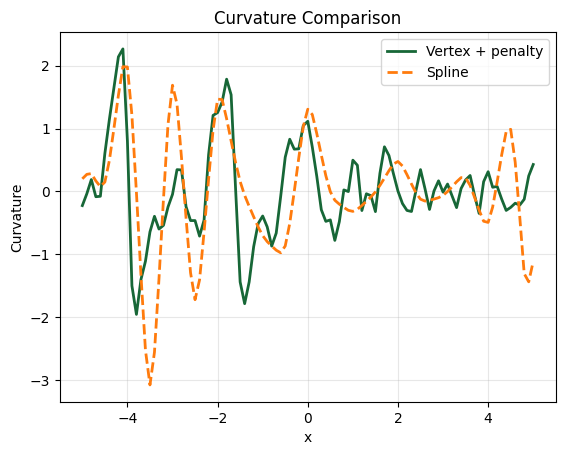

In [ ]:
# get the vertices of the best vertex parametrized design
ys_best_vertex = get_ys(params_best_vertex)

# get the vertices of the best spline parametrized design
ys_spline_control = get_ys(params_best_spline)
xs_spline_final, ys_spline_final = interpolate_spline(
    xs_spline_control,
    ys_spline_control,
    num_points=num_points_interpolated,
    order=3,
    endpoint_derivatives=(0, 0),
)

# Calculate curvature
d2ys_vertex_dx2 = np.gradient(np.gradient(ys_best_vertex, xs), xs)
d2ys_spline_dx2 = np.gradient(np.gradient(ys_spline_final, xs_spline_final), xs_spline_final)

# Plot curvature comparison
f, ax = plt.subplots()
ax.plot(xs, d2ys_vertex_dx2, "-", label="Vertex + penalty", linewidth=2)
ax.plot(xs_spline_final, d2ys_spline_dx2, "--", label="Spline", linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel("Curvature")
ax.set_title("Curvature Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Taper Shapes

Here are the final taper shapes, with curvature magnitude overlaid at the boundaries.

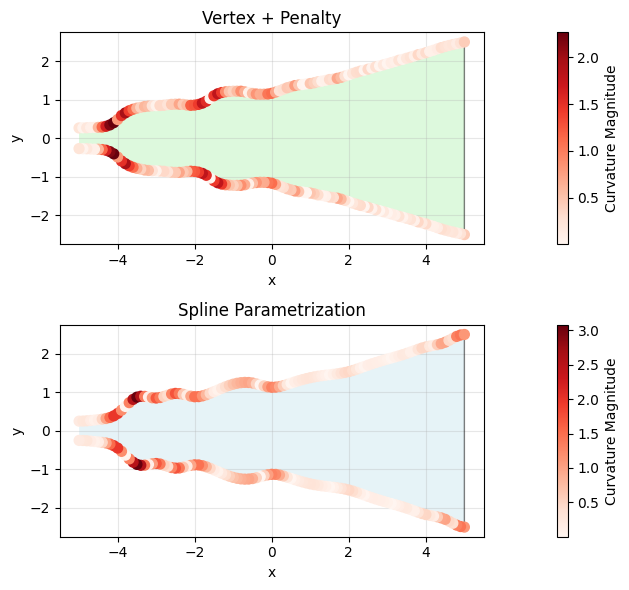

In [ ]:
# Create the full polygon by mirroring the spline vertices
xs_spline_full = np.concatenate([xs_spline_final, xs_spline_final[::-1]])
ys_spline_full = np.concatenate([ys_spline_final, -ys_spline_final[::-1]])

# Mirror the curvature as well for spline
d2ys_spline_full_dx2 = np.concatenate([d2ys_spline_dx2, d2ys_spline_dx2[::-1]])

# Create the full polygon for the vertex parametrized design
xs_vertex_full = np.concatenate([xs, xs[::-1]])
ys_vertex_full = np.concatenate([ys_best_vertex, -ys_best_vertex[::-1]])

# Mirror the curvature for the vertex design
d2ys_vertex_full_dx2 = np.concatenate([d2ys_vertex_dx2, d2ys_vertex_dx2[::-1]])

# Use absolute value of curvature for color mapping
curvature_spline_abs = np.abs(d2ys_spline_full_dx2)
curvature_vertex_abs = np.abs(d2ys_vertex_full_dx2)

# Create subplots
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6))

# Plot vertex parametrized design
polygon_vertex = plt.Polygon(
    list(zip(xs_vertex_full, ys_vertex_full)), alpha=0.3, facecolor="lightgreen", edgecolor="none"
)
ax1.add_patch(polygon_vertex)
scatter1 = ax1.scatter(
    xs_vertex_full, ys_vertex_full, c=curvature_vertex_abs, cmap="Reds", s=50, zorder=5
)
ax1.plot(xs_vertex_full, ys_vertex_full, "k-", alpha=0.5, linewidth=1)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Vertex + Penalty")
ax1.grid(True, alpha=0.3)
ax1.set_aspect("equal")

# Plot spline parametrized design
polygon_spline = plt.Polygon(
    list(zip(xs_spline_full, ys_spline_full)), alpha=0.3, facecolor="lightblue", edgecolor="none"
)
ax2.add_patch(polygon_spline)
scatter2 = ax2.scatter(
    xs_spline_full, ys_spline_full, c=curvature_spline_abs, cmap="Reds", s=50, zorder=5
)
ax2.plot(xs_spline_full, ys_spline_full, "k-", alpha=0.5, linewidth=1)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Spline Parametrization")
ax2.grid(True, alpha=0.3)
ax2.set_aspect("equal")

cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label("Curvature Magnitude")
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label("Curvature Magnitude")

plt.tight_layout()
plt.show()

## Conclusion

We demonstrated how `interpolate_spline` can be used as an alternative to the curvature penalty approach for producing smooth, fabricable taper designs via inverse design.

| | Vertex + Curvature Penalty | Spline Interpolation |
|---|---|---|
| **Design parameters** | 101 (all vertices) | 21 (control points) |
| **Smoothness** | Enforced via penalty | Inherent from spline |
| **Penalty term** | Required | Not needed |
| **Performance** | ~99.8% transmission | ~99.7% transmission |

Both approaches achieve comparable results. The spline approach offers a simpler optimization formulation with fewer parameters and no need to tune penalty weights, while the vertex approach provides more direct control over individual vertex positions.

For more details on the vertex + curvature penalty approach, see [Tutorial 5: Boundary Gradients](https://docs.flexcompute.com/projects/tidy3d/en/latest/notebooks/Autograd5BoundaryGradients.html).